## Investigation Overview

This analysis explores how different types of users interact with a bike-sharing system.  
The main focus is to understand how trip duration and usage patterns vary between Subscribers and Customers.

## Dataset Overview

The dataset contains information about bike trips, including trip duration, user type, time of usage, and user demographics.  
The data was cleaned and processed to remove missing values and create additional features such as age and hour of usage.

In [13]:
# Import libraries
import numpy as np # linear algebra
import pandas as pd
import matplotlib.pyplot as plt # plotting
import seaborn as sns

# Show plots inline
%matplotlib inline 

In [14]:
# Load original dataset
df = pd.read_csv('201902-fordgobike-tripdata.csv')

# Create cleaned copy
df_clean = df.copy()

# Convert time columns
df_clean['start_time'] = pd.to_datetime(df_clean['start_time'])
df_clean['end_time'] = pd.to_datetime(df_clean['end_time'])

# Create useful features
df_clean['start_hour'] = df_clean['start_time'].dt.hour
df_clean['age'] = 2019 - df_clean['member_birth_year']

# Clean data
df_clean = df_clean[df_clean['duration_sec'] < 5000]
df_clean = df_clean[(df_clean['age'] > 0) & (df_clean['age'] < 100)]
df_clean = df_clean.dropna(subset=['member_gender', 'member_birth_year'])

Text(0, 0.5, 'Number of Trips')

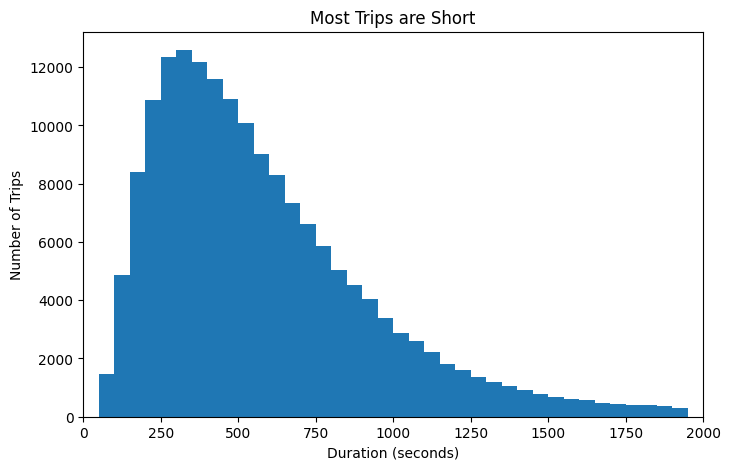

In [15]:
plt.figure(figsize=(8,5))

bins = np.arange(0, 2000, 50)
plt.hist(data=df_clean, x='duration_sec', bins=bins)

plt.xlim(0, 2000)  

plt.title('Most Trips are Short')
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of Trips')

### Distribution of Trip Duration

Most trips are short, with the highest concentration between 200 and 600 seconds.  
The distribution is right-skewed, indicating that longer trips exist but are relatively rare.  

By limiting the x-axis to 2000 seconds, the visualization highlights the main pattern without distraction from extreme values.

Text(0, 0.5, 'Duration (seconds)')

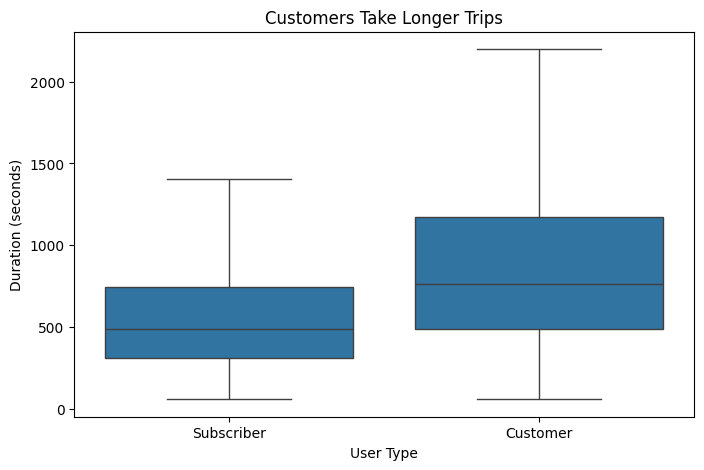

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df_clean, x='user_type', y='duration_sec', showfliers=False)

plt.title('Customers Take Longer Trips')
plt.xlabel('User Type')
plt.ylabel('Duration (seconds)')

### Trip Duration by User Type

Customers take longer trips compared to Subscribers.  
The median trip duration for Customers is noticeably higher, and their trip durations are more spread out.  

In contrast, Subscribers tend to have shorter and more consistent trip durations.  

This suggests that Subscribers primarily use the service for daily commuting, while Customers are more likely to use it for leisure or longer rides.

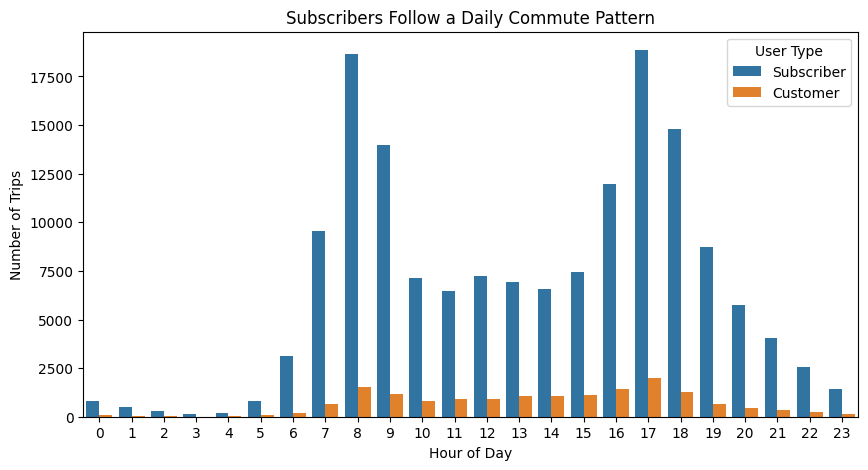

In [17]:
plt.figure(figsize=(10,5))

sns.countplot(data=df_clean, x='start_hour', hue='user_type')

plt.title('Subscribers Follow a Daily Commute Pattern')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.legend(title='User Type')

### Usage by Hour and User Type

Subscribers show clear peaks in usage during the early morning (around 8 AM) and late afternoon (5–6 PM).  
These times align with typical commuting hours, indicating that Subscribers use the bike-sharing system for daily transportation.

In contrast, Customers have lower usage and do not show strong peaks, suggesting more flexible and recreational use.

This highlights a clear behavioral difference between the two user groups.

## Conclusion

The analysis reveals clear behavioral differences between Subscribers and Customers.

Subscribers primarily use the bike-sharing system for daily commuting, as shown by short trip durations and strong usage during peak hours.

Customers, on the other hand, tend to take longer trips and use the system more flexibly throughout the day.

These findings indicate that the system serves both as a practical transportation solution and a recreational service.